# Magnetic symmetry check: Y2Ir2O7 mode-1 pair

The AIAO base structure breaks time reversal, so its Berry curvature is not pointwise zero at generic k. The useful checks are instead the covariance of the Cartesian dual trace curvature

$$\omega = (\mathrm{Tr}\,\Omega_{yz}, \mathrm{Tr}\,\Omega_{zx}, \mathrm{Tr}\,\Omega_{xy})$$

under the magnetic point group. For a spatial operation R: `omega(Rk) = det(R) R omega(k)` (unitary), `omega(-Rk) = -det(R) R omega(k)` (antiunitary R.T).

Also evaluates simple invariant-line consequences: base z axis (all components vanish, two unitary mirrors); mode 1 z axis (**all** components vanish: the unitary C2z gives `omega_x = omega_y = 0`, and the antiunitary S4z T, which also fixes the axis, leaves no allowed direction for `omega_z`); mode 1 [111] axis (`omega_x = omega_y = omega_z`, unitary C3); mode 1 [1,-1,0] axis (`omega_x = omega_y`, antiunitary M_xy T).

`POSITION_SOURCE` picks the position matrix: `mmn` (rebuilt from the overlaps), `rdat` (Wannier90's `_r.dat` with the in-house Wigner-Seitz remapping) or `jaemo` (Jae-Mo's `write_ndegen_applied` files in `<run>/jaemo/`, read by PythTB exactly as written, no remapping). The internal/cross/external decomposition is `modules/curvature.py`'s.

Two kinds of test calibrate the others.

* `base_S4z_control` and `mode1_S4z_control` apply S4z **without** time reversal, which is not a symmetry of either structure. Both structures are nearly inversion symmetric, so the true relation is `omega(S4z k) = +S4z omega(k)` while the unitary test predicts `-S4z omega(k)`: the residual should be about twice the curvature (a relative residual near 2). If it is not, the covariance test cannot tell a broken symmetry from a kept one.
* `mode1_inversion` is *not* a symmetry of mode 1, but the displacement breaks it only at order Q, so at Q = 0.01 A its residual is expected to sit at the same floor as the real symmetries. It measures whether the displacement is resolvable at all; set against `base_inversion` it also shows whether the floor is common to the two structures.

Set `RUN_COMPUTATION = False` to load the last saved run from `results/magnetic_symmetry/`. The base and mode-1 models are large (Y2Ir2O7, 176 WF) and are loaded and released sequentially -- this notebook keeps that structure as two separate cells rather than holding both models in memory at once.

In [1]:
import csv
import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pythtb import W90

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "validation").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from validation._paths import (
    RESULTS,
    YIO,
    YIO_AA_CACHE,
    YIO_BASE,
    YIO_MODE1,
    YIO_N_OCCUPIED,
)
from validation._paths import DATA
from modules import curvature as cv
from wannier.position_matrix import (
    apply_orbital_dependent_R_mapping,
    apply_rdat_pair_convention,
    build_position_matrix_from_mmn,
)

PREFIX = "Y2Ir2O7"
N_OCCUPIED = YIO_N_OCCUPIED

# Cartesian spatial parts printed by QE for the magnetic symmetry operations.
C2Z = np.diag([-1.0, -1.0, 1.0])
C3_111 = np.array([[0.0, 0.0, 1.0],
                   [1.0, 0.0, 0.0],
                   [0.0, 1.0, 0.0]])
MXY = np.array([[0.0, 1.0, 0.0],
                [1.0, 0.0, 0.0],
                [0.0, 0.0, 1.0]])
INVERSION = -np.eye(3)
# 90 degree rotation about z followed by z -> -z.  S4z T (with time reversal) is in -4'3m'; S4z alone is not.
S4Z = np.array([[0.0, 1.0, 0.0],
                [-1.0, 0.0, 0.0],
                [0.0, 0.0, -1.0]])

## Helper functions

In [2]:
def trace_curvature_vector(model, pos, kpoints, batch_size):
    """Return internal/cross/external/total Cartesian trace-curvature vectors."""
    kpoints = np.asarray(kpoints, dtype=float)
    reciprocal_inverse = np.linalg.inv(
        np.asarray(model.recip_lat_vecs, dtype=float)
    )
    pieces = {name: [] for name in ("internal", "cross", "external", "total")}

    for start in range(0, len(kpoints), batch_size):
        stop = min(start + batch_size, len(kpoints))
        k_batch = kpoints[start:stop]
        c = cv.connection(cv.fields(model, pos, k_batch), N_OCCUPIED)
        omega = {
            "internal": cv.omega_internal(c),
            "cross": cv.omega_cross(c),
            "external": cv.omega_external(c),
        }
        omega["total"] = omega["internal"] + omega["cross"] + omega["external"]  # eq (24)

        for name in pieces:
            value = omega[name]
            value_cartesian = np.einsum(
                "ia,jb,ab...->ij...",
                reciprocal_inverse,
                reciprocal_inverse,
                value,
                optimize=True,
            )
            trace = np.trace(value_cartesian, axis1=-2, axis2=-1)
            pieces[name].append(
                np.stack((trace[1, 2], trace[2, 0], trace[0, 1]), axis=-1)
            )
        del c, omega
        gc.collect()

    return {name: np.concatenate(values, axis=0) for name, values in pieces.items()}


def transformed_kpoints(kpoints, reciprocal_lattice, rotation, antiunitary):
    """Apply k -> Rk or k -> -Rk and return reduced reciprocal coordinates."""
    k_cartesian = np.asarray(kpoints) @ reciprocal_lattice
    sign = -1.0 if antiunitary else 1.0
    transformed_cartesian = sign * k_cartesian @ rotation.T
    return transformed_cartesian @ np.linalg.inv(reciprocal_lattice)


def load_model(directory, cache, embedding=None, position_source="mmn"):
    """Load one production model so base and mode need not coexist in memory.

    ``position_source`` selects where ``<0i|r|Rj>`` comes from: ``mmn`` rebuilds
    it from the overlaps with the right-centre link phase, ``rdat`` reads
    Wannier90's ``_r.dat`` and applies the ``use_ws_distance`` remapping in
    house.  The second needs no ``.mmn`` at all, which is the reason to test it.
    ``jaemo`` reads ``<directory>/jaemo`` (Jae-Mo's ``write_ndegen_applied`` files) exactly as
    written: ``H(R)`` and ``A(R)`` are final, so no remapping is applied.
    """
    print(f"Loading {directory}  [position source: {position_source}]", flush=True)
    options = dict(
        zero_energy=0,
        min_hopping_norm=1e-5,
        max_distance=125,
        ignorable_imaginary_part=None,
    )
    if position_source == "jaemo":
        w90 = W90(str(Path(directory) / "jaemo"), PREFIX)
        if embedding is None:
            model = w90.model(**options)
            embedding = model.orb_vecs.copy()
        else:
            model = w90.model(orb_vecs=embedding, **options)
        del w90
        gc.collect()
        print(f"  model: {model.norb} orbitals, H(R)={len(model._ham_r)}, A(R)={len(model._pos_r)}", flush=True)
        return model, embedding
    w90 = W90(str(directory), PREFIX)
    position_R = None
    if position_source == "rdat":
        position_R, rdat_info = apply_rdat_pair_convention(
            w90, (8, 8, 8), R_distance_tolerance=1e-5, verbose=True
        )
    else:
        apply_orbital_dependent_R_mapping(w90, (8, 8, 8), verbose=True)
    if embedding is None:
        model = w90.model(**options)
        embedding = model.orb_vecs.copy()
    else:
        model = w90.model(orb_vecs=embedding, **options)
    del w90
    gc.collect()
    if position_source == "rdat":
        # w90.model prunes H(R) by min_hopping_norm/max_distance.  Restrict A
        # to the surviving set so both operators use literally the same R
        # vectors -- this is what build_position_matrix_from_mmn does too.
        kept = set(model._ham_r)
        dropped = len(position_R) - len(kept & set(position_R))
        model._pos_r = {R: position_R[R] for R in kept if R in position_R}
        missing = kept - set(position_R)
        if missing:
            raise ValueError(
                f"{len(missing)} H(R) vectors have no _r.dat position block"
            )
        del position_R
        gc.collect()
        info = {
            "mmn_pair_hermiticity_relative":
                rdat_info["rdat_pair_hermiticity_relative"],
        }
        print(f"  A(R) restricted to the pruned H(R) set: dropped {dropped}",
              flush=True)
    else:
        info = build_position_matrix_from_mmn(
            model, directory, PREFIX, cache=cache
        )
    print(
        f"  model: {model.norb} orbitals, "
        f"H(R)={len(model._ham_r)}, A(R)={len(model._pos_r)}; "
        f"MMN hermiticity={info['mmn_pair_hermiticity_relative']:.3e}",
        flush=True,
    )
    del info
    gc.collect()
    return model, embedding


def covariance_expectation(test):
    """The label that goes with a covariance test in metrics.csv."""
    if test.endswith("_control"):
        return "control: S4z without T is NOT a symmetry; expect a residual of order the curvature"
    if test == "mode1_inversion":
        return "not a symmetry of mode 1, but broken only at O(Q): at 0.01 A it sits at the floor"
    return "magnetic-symmetry covariance"


def add_metric(rows, test, structure, part, residual, scale, expectation):
    """Append one compact maximum-residual summary."""
    residual = float(np.max(np.abs(residual)))
    scale = float(np.max(np.abs(scale)))
    rows.append({
        "test": test,
        "structure": structure,
        "part": part,
        "max_residual_A2": residual,
        "curvature_scale_A2": scale,
        "relative_residual": residual / max(scale, 1e-30),
        "expectation": expectation,
    })

## Config

In [3]:
RUN_COMPUTATION = True  # True: load both models and recompute. False: load results/magnetic_symmetry/.
N_POINTS = 17
BATCH_SIZE = 4
OUTPUT_DIR = RESULTS / "magnetic_symmetry_jaemo_qe76"
POSITION_SOURCE = "jaemo"  # "mmn" (default), "rdat" (no .mmn needed) or "jaemo" (<run>/jaemo/, read as written)
BASE_DIRECTORY = DATA / "Y2Ir2O7/base/soc/u_3.0/output/192344bc889/trial_02_Y_p_Ir_d_O_sp/192473bc889"  # QE 7.6 + new_ns_nc fix
MODE_DIRECTORY = DATA / "Y2Ir2O7/phonon/GM2-/mode1/Q_0.01A/output/192345/trial_02_Y_p_Ir_d_O_sp/no-displacement/192908bc889"  # QE 7.6 + new_ns_nc fix
AA_CACHE_FILES = {
    "base": DATA / "Y2Ir2O7/phonon/_AA_cache/AA_trial_02_Y_p_Ir_d_O_sp_base_181538bc889.npz",
    "mode": DATA / "Y2Ir2O7/phonon/_AA_cache/AA_trial_02_Y_p_Ir_d_O_sp_mode_181565bc889.npz",
}

# Generic points test complete covariance, not just special-locus zeros.
rng = np.random.default_rng(20260825)
generic_cartesian = rng.uniform(-0.23, 0.23, size=(7, 3))
operations = {
    "base": {
        "base_inversion": (INVERSION, False),
        "base_S4z_control": (S4Z, False),  # NOT a symmetry (no time reversal): a control
    },
    "mode1": {
        "mode1_C2z": (C2Z, False),
        "mode1_C3_111": (C3_111, False),
        "mode1_MxyT": (MXY, True),
        "mode1_S4zT": (S4Z, True),  # the operation that removes omega_z on the z axis
        "mode1_inversion": (INVERSION, False),  # broken by the mode, but only at O(Q)
        "mode1_S4z_control": (S4Z, False),  # NOT a symmetry (no time reversal): a control
    },
}
q = np.linspace(-0.25, 0.25, N_POINTS)
directions = {
    "z_axis": np.array([0.0, 0.0, 1.0]),
    "axis_111": np.array([1.0, 1.0, 1.0]) / np.sqrt(3.0),
    "axis_1m10": np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0),
}
arrays = {"q_cartesian_Ainv": q}
rows = []

## Base structure

Loads the AIAO base model, evaluates the generic-point curvature (`original_base`), the inversion covariance test, and the z-axis invariant line (`base_z`). Releases the model afterward -- `embedding` (the Wannier centres) is kept and reused verbatim for mode 1.

In [4]:
if RUN_COMPUTATION:
    model, embedding = load_model(BASE_DIRECTORY, AA_CACHE_FILES["base"], None, POSITION_SOURCE)
    pos = cv.position_terms(model, dtype=np.complex128)  # tau = embedding = model.orb_vecs
    reciprocal = np.asarray(model.recip_lat_vecs, dtype=float)
    reciprocal_inverse = np.linalg.inv(reciprocal)
    generic = generic_cartesian @ reciprocal_inverse
    arrays["generic_k_reduced"] = generic
    line_kpoints = {
        name: (q[:, None] * direction) @ reciprocal_inverse
        for name, direction in directions.items()
    }

    print("Evaluating base generic curvature", flush=True)
    original_base = trace_curvature_vector(model, pos, generic, BATCH_SIZE)
    for test, (rotation, antiunitary) in operations["base"].items():
        print(f"  covariance: {test}", flush=True)
        transformed = transformed_kpoints(generic, reciprocal, rotation, antiunitary)
        evaluated = trace_curvature_vector(model, pos, transformed, BATCH_SIZE)
        factor = (-1.0 if antiunitary else 1.0) * np.linalg.det(rotation)
        arrays[f"{test}__k_transformed_reduced"] = transformed
        for part, original_part in original_base.items():
            predicted = factor * original_part @ rotation.T
            residual = evaluated[part] - predicted
            arrays[f"{test}__{part}__evaluated"] = evaluated[part]
            arrays[f"{test}__{part}__predicted"] = predicted
            arrays[f"{test}__{part}__residual"] = residual
            add_metric(rows, test, "base", part, residual,
                       np.concatenate((evaluated[part], predicted)),
                       covariance_expectation(test))

        energies, energies_transformed = [], []
        for start in range(0, len(generic), BATCH_SIZE):
            stop = min(start + BATCH_SIZE, len(generic))
            energies.append(np.linalg.eigvalsh(model.hamiltonian(generic[start:stop], flatten_spin_axis=True)))
            energies_transformed.append(np.linalg.eigvalsh(model.hamiltonian(transformed[start:stop], flatten_spin_axis=True)))
        energy_residual = np.concatenate(energies_transformed) - np.concatenate(energies)
        rows.append({
            "test": test + "_bands", "structure": "base", "part": "eigenvalues",
            "max_residual_A2": np.nan, "curvature_scale_A2": np.nan, "relative_residual": np.nan,
            "expectation": f"max band residual = {np.max(np.abs(energy_residual)):.9e} eV",
        })
        arrays[f"{test}__band_residual_eV"] = energy_residual

    print("Evaluating base invariant lines", flush=True)
    base_z = trace_curvature_vector(model, pos, line_kpoints["z_axis"], BATCH_SIZE)
    for part, value in base_z.items():
        arrays[f"base_z_axis__{part}"] = value
        add_metric(rows, "base_mirror_intersection", "base", part, value,
                   original_base[part], "omega_x = omega_y = omega_z = 0")

    del pos, model
    gc.collect()

Loading /Users/treycole/Repos/axion-phonon/data/Y2Ir2O7/base/soc/u_3.0/output/192344bc889/trial_02_Y_p_Ir_d_O_sp/192473bc889  [position source: jaemo]


  model: 176 orbitals, H(R)=1097, A(R)=1097


Evaluating base generic curvature


  covariance: base_inversion


  covariance: base_S4z_control


Evaluating base invariant lines


## Mode-1 structure

Loads the mode-1 model with the base's embedding, evaluates the generic-point curvature (`original_mode1`), the C2z/C3/MxyT covariance tests, and the z/[111]/[1,-1,0] invariant lines (`mode_z`, `mode_111`, `mode_1m10`).

In [5]:
if RUN_COMPUTATION:
    model, embedding = load_model(MODE_DIRECTORY, AA_CACHE_FILES["mode"], embedding, POSITION_SOURCE)
    pos = cv.position_terms(model, dtype=np.complex128)  # tau = embedding = model.orb_vecs
    model_reciprocal = np.asarray(model.recip_lat_vecs, dtype=float)
    if not np.allclose(model_reciprocal, reciprocal, atol=1e-12):
        raise ValueError("Base and mode reciprocal lattices differ")

    print("Evaluating mode1 generic curvature", flush=True)
    original_mode1 = trace_curvature_vector(model, pos, generic, BATCH_SIZE)
    for test, (rotation, antiunitary) in operations["mode1"].items():
        print(f"  covariance: {test}", flush=True)
        transformed = transformed_kpoints(generic, reciprocal, rotation, antiunitary)
        evaluated = trace_curvature_vector(model, pos, transformed, BATCH_SIZE)
        factor = (-1.0 if antiunitary else 1.0) * np.linalg.det(rotation)
        arrays[f"{test}__k_transformed_reduced"] = transformed
        for part, original_part in original_mode1.items():
            predicted = factor * original_part @ rotation.T
            residual = evaluated[part] - predicted
            arrays[f"{test}__{part}__evaluated"] = evaluated[part]
            arrays[f"{test}__{part}__predicted"] = predicted
            arrays[f"{test}__{part}__residual"] = residual
            add_metric(rows, test, "mode1", part, residual,
                       np.concatenate((evaluated[part], predicted)),
                       covariance_expectation(test))

        energies, energies_transformed = [], []
        for start in range(0, len(generic), BATCH_SIZE):
            stop = min(start + BATCH_SIZE, len(generic))
            energies.append(np.linalg.eigvalsh(model.hamiltonian(generic[start:stop], flatten_spin_axis=True)))
            energies_transformed.append(np.linalg.eigvalsh(model.hamiltonian(transformed[start:stop], flatten_spin_axis=True)))
        energy_residual = np.concatenate(energies_transformed) - np.concatenate(energies)
        rows.append({
            "test": test + "_bands", "structure": "mode1", "part": "eigenvalues",
            "max_residual_A2": np.nan, "curvature_scale_A2": np.nan, "relative_residual": np.nan,
            "expectation": f"max band residual = {np.max(np.abs(energy_residual)):.9e} eV",
        })
        arrays[f"{test}__band_residual_eV"] = energy_residual

    print("Evaluating mode1 invariant lines", flush=True)
    mode_z = trace_curvature_vector(model, pos, line_kpoints["z_axis"], BATCH_SIZE)
    mode_111 = trace_curvature_vector(model, pos, line_kpoints["axis_111"], BATCH_SIZE)
    mode_1m10 = trace_curvature_vector(model, pos, line_kpoints["axis_1m10"], BATCH_SIZE)
    for name, values in (("mode1_z_axis", mode_z), ("mode1_111_axis", mode_111), ("mode1_1m10_axis", mode_1m10)):
        for part, value in values.items():
            arrays[f"{name}__{part}"] = value
    for part in ("internal", "cross", "external", "total"):
        add_metric(rows, "mode1_z_axis", "mode1", part, mode_z[part], original_mode1[part],
                   "omega = 0 (C2z: omega_x = omega_y = 0; S4z T: no allowed direction)")
        add_metric(rows, "mode1_C3_111_axis", "mode1", part,
                   np.column_stack((mode_111[part][:, 0] - mode_111[part][:, 1],
                                    mode_111[part][:, 1] - mode_111[part][:, 2])),
                   mode_111[part], "omega_x = omega_y = omega_z")
        add_metric(rows, "mode1_MxyT_fixed_line", "mode1", part,
                   mode_1m10[part][:, 0] - mode_1m10[part][:, 1], mode_1m10[part], "omega_x = omega_y")
    gamma_index = int(np.argmin(np.abs(q)))
    add_metric(rows, "mode1_Gamma", "mode1", "total", mode_z["total"][gamma_index], original_mode1["total"],
               "all components vanish")

    del pos, model
    gc.collect()

Loading /Users/treycole/Repos/axion-phonon/data/Y2Ir2O7/phonon/GM2-/mode1/Q_0.01A/output/192345/trial_02_Y_p_Ir_d_O_sp/no-displacement/192908bc889  [position source: jaemo]


  model: 176 orbitals, H(R)=1097, A(R)=1097


Evaluating mode1 generic curvature


  covariance: mode1_C2z


  covariance: mode1_C3_111


  covariance: mode1_MxyT


  covariance: mode1_S4zT


  covariance: mode1_inversion


  covariance: mode1_S4z_control


Evaluating mode1 invariant lines


## Save

In [6]:
if RUN_COMPUTATION:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        OUTPUT_DIR / "symmetry_checks.npz",
        **arrays,
        base_directory=np.array([str(BASE_DIRECTORY.relative_to(DATA))]),
        mode_directory=np.array([str(MODE_DIRECTORY.relative_to(DATA))]),
        position_source=np.array([POSITION_SOURCE]),
        orbital_dependent_R=np.int8(POSITION_SOURCE != "jaemo"),
        n_occupied=np.int32(N_OCCUPIED),
    )
    with (OUTPUT_DIR / "metrics.csv").open("w", newline="") as stream:
        writer = csv.DictWriter(stream, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)
    print(f"saved {OUTPUT_DIR / 'metrics.csv'}")
    print(f"saved {OUTPUT_DIR / 'symmetry_checks.npz'}")

    print("\nTotal-curvature residuals")
    for row in rows:
        if row["part"] != "total":
            continue
        print(f"  {row['test']:<31s} residual={row['max_residual_A2']:.3e} A^2  "
              f"scale={row['curvature_scale_A2']:.3e} A^2  relative={row['relative_residual']:.3e}")

saved /Users/treycole/Repos/axion-phonon/validation/results/magnetic_symmetry_jaemo_qe76/metrics.csv
saved /Users/treycole/Repos/axion-phonon/validation/results/magnetic_symmetry_jaemo_qe76/symmetry_checks.npz

Total-curvature residuals
  base_inversion                  residual=9.352e-02 A^2  scale=6.162e-01 A^2  relative=1.518e-01
  base_S4z_control                residual=1.229e+00 A^2  scale=6.162e-01 A^2  relative=1.995e+00
  base_mirror_intersection        residual=3.135e-02 A^2  scale=6.162e-01 A^2  relative=5.087e-02
  mode1_C2z                       residual=5.329e-02 A^2  scale=6.204e-01 A^2  relative=8.590e-02
  mode1_C3_111                    residual=7.482e-02 A^2  scale=6.110e-01 A^2  relative=1.224e-01
  mode1_MxyT                      residual=1.440e-02 A^2  scale=6.189e-01 A^2  relative=2.326e-02
  mode1_S4zT                      residual=3.635e-02 A^2  scale=6.109e-01 A^2  relative=5.950e-02
  mode1_inversion                 residual=9.218e-02 A^2  scale=6.298e-01 A^2

## Load previously saved results (skip if you just computed above)

In [7]:
if not RUN_COMPUTATION:
    data = np.load(OUTPUT_DIR / "symmetry_checks.npz")
    q = data["q_cartesian_Ainv"]
    base_z = {part: data[f"base_z_axis__{part}"] for part in ("internal", "cross", "external", "total")}
    mode_z = {part: data[f"mode1_z_axis__{part}"] for part in ("internal", "cross", "external", "total")}
    mode_111 = {part: data[f"mode1_111_axis__{part}"] for part in ("internal", "cross", "external", "total")}
    mode_1m10 = {part: data[f"mode1_1m10_axis__{part}"] for part in ("internal", "cross", "external", "total")}
    with (OUTPUT_DIR / "metrics.csv").open() as stream:
        rows = list(csv.DictReader(stream))
    print("\nTotal-curvature residuals")
    for row in rows:
        if row["part"] != "total":
            continue
        print(f"  {row['test']:<31s} residual={row['max_residual_A2']:<12s} scale={row['curvature_scale_A2']:<12s} relative={row['relative_residual']}")

## Plot

saved /Users/treycole/Repos/axion-phonon/validation/results/magnetic_symmetry_jaemo_qe76/symmetry_checks.png


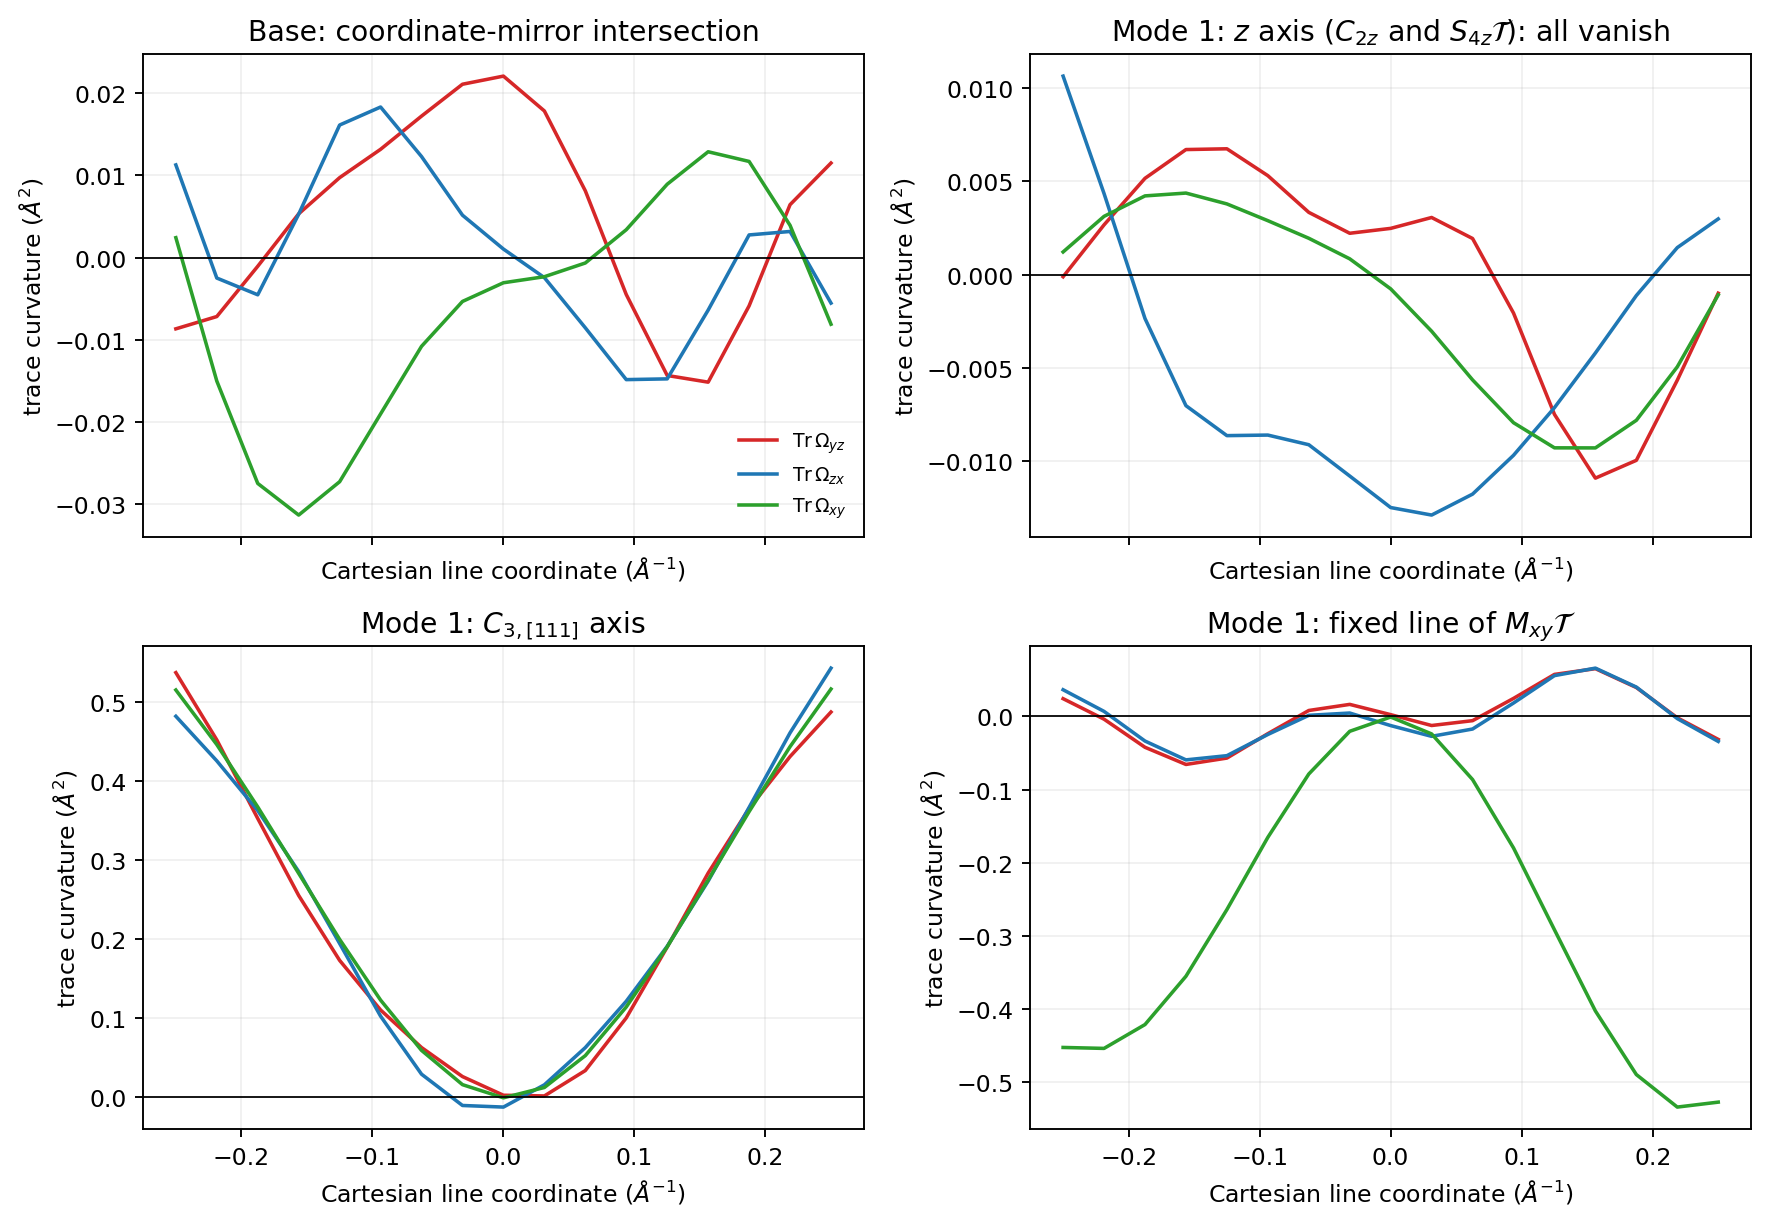

In [8]:
total = "total"
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.3), dpi=170, sharex=True)
component_labels = (
    r"$\mathrm{Tr}\,\Omega_{yz}$",
    r"$\mathrm{Tr}\,\Omega_{zx}$",
    r"$\mathrm{Tr}\,\Omega_{xy}$",
)
colors = ("#d62728", "#1f77b4", "#2ca02c")

for component in range(3):
    axes[0, 0].plot(q, base_z[total][:, component].real, color=colors[component], label=component_labels[component])
axes[0, 0].set_title("Base: coordinate-mirror intersection")

for component in range(3):
    axes[0, 1].plot(q, mode_z[total][:, component].real, color=colors[component], label=component_labels[component])
axes[0, 1].set_title(r"Mode 1: $z$ axis ($C_{2z}$ and $S_{4z}\mathcal{T}$): all vanish")

for component in range(3):
    axes[1, 0].plot(q, mode_111[total][:, component].real, color=colors[component], label=component_labels[component])
axes[1, 0].set_title(r"Mode 1: $C_{3,[111]}$ axis")

for component in range(3):
    axes[1, 1].plot(q, mode_1m10[total][:, component].real, color=colors[component], label=component_labels[component])
axes[1, 1].set_title(r"Mode 1: fixed line of $M_{xy}\mathcal{T}$")

for ax in axes.flat:
    ax.axhline(0.0, color="black", linewidth=0.75)
    ax.set_xlabel(r"Cartesian line coordinate ($\AA^{-1}$)")
    ax.set_ylabel(r"trace curvature ($\AA^2$)")
    ax.grid(alpha=0.18)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
if RUN_COMPUTATION:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "symmetry_checks.png", bbox_inches="tight")
    print(f"saved {OUTPUT_DIR / 'symmetry_checks.png'}")
plt.show()